[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

# 투빅스 25&26기 2주차 2교시 — Deep Learning 과제 [sklearn `digits` 손글씨 분류]


## 과제 목적

이번 과제는 `sklearn`의 `digits` 데이터셋을 이용해 **MLP를 직접 학습**하고, DNN의 세 가지 고질병인 **Vanishing Gradient · Overfitting · Optimization**을 실제 실험 결과로 확인하는 프로젝트입니다. §1.1에서는 데이터를 확인하고 train / validation / test로 분리하며, §1.2에서는 PyTorch로 미니배치 SGD 학습 루프를 완성합니다. 이어지는 §1.3~1.5에서는 활성화 함수, 규제 방법, optimizer를 하나씩 바꾸며 강의의 설명이 실제 학습 곡선과 수치에서 어떻게 나타나는지 검증합니다. 마지막 심화(§2)에서는 "활성화 함수가 없으면 층을 쌓아도 선형모델"이라는 주장을 직접 확인하고, 파라미터 수를 맞춘 Wide vs Deep 비교를 통해 "Deep이 항상 더 좋은가"를 본인 실험으로 판단합니다.

## 주의 사항
각 코드 셀의 빈칸(`# TODO: ____`, `____`)을 채우며 **"지금 어느 단계에서 무엇을 하고 있는가"**를 확인하세요. 앞 단계에서 만든 변수와 함수가 뒤 절에서 계속 사용되므로 **맨 위 셀부터 순서대로** 실행해야 합니다.


## 제출물

1. 빈칸을 모두 채우고 **전부 실행한** 이 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션 — §1.3~1.5의 실험 결과 그래프와 본인 해석을 옮겨 정리


---

## 0. 환경 설정 — 라이브러리, 시드, 데이터 로드

이번 과제는 **별도 파일 업로드가 필요 없습니다.** scikit-learn에 내장된 **`load_digits()`** 를 씁니다.

- **무슨 데이터?** 손글씨 숫자 이미지 **1,797장**. 각 이미지는 **8×8 = 64 픽셀**, 픽셀 값은 **0~16**의 정수(밝기). 정답은 **0~9의 10개 클래스**입니다.
- **왜 이 데이터?** 강의의 마지막 슬라이드 구조(`Input → Hidden → Output`, `# of nodes: 변수 개수(d) / 자유 / Task에 의존`)를 그대로 적용할 수 있습니다. 입력 노드는 **64개(픽셀 수 = d)**, 출력 노드는 **10개(클래스 수 = Task에 의존)**, 은닉층은 **자유**입니다. 그리고 크기가 작아 Colab CPU에서도 실험 하나가 몇 초면 끝나므로, **여러 조건을 비교**하는 이번 과제에 적합합니다.

이 셀에서 하는 일은 세 가지입니다.

**1) 라이브러리 import.** 이후 모든 셀이 여기서 불러온 이름(`np`, `torch`, `nn` 등)을 씁니다. 한 번만 실행하면 됩니다.

**2) `MY_SEED` 설정.** *시드(seed)* 는 난수 생성기의 출발점입니다. 딥러닝에는 무작위가 **최소 세 군데** 들어갑니다 — ① **가중치 초기화**, ② **train/val/test 분할**, ③ **미니배치 셔플 순서**. 시드를 고정해야 재현이 되고 채점이 가능합니다.

**3) 데이터 로드.** `load_digits()`는 sklearn 패키지 안에 들어 있어 인터넷 없이도 즉시 로드됩니다.

> 시드를 고정한다고 결과가 **편향**되는 것은 아닙니다. 무작위 절차를 **재현 가능**하게 만들 뿐입니다.

In [ ]:
# ── 라이브러리 import (한 번만 실행; 이후 모든 셀이 이 이름을 그대로 사용) ──
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── 0. 환경 설정 ──────────────────────────────────────────────
# (1) 시드 설정 — 본인 학번 뒷 4자리를 넣으세요 (예: 2026-12345 → 2345)
MY_SEED = 8734              # TODO: 학번 뒷 4자리
np.random.seed(MY_SEED)        # TODO: NumPy 난수 고정
torch.manual_seed(MY_SEED)     # TODO: PyTorch 난수 고정 (가중치 초기화·셔플에 영향)

# (2) 데이터 로드 — sklearn 내장 데이터라 다운로드/업로드가 필요 없다
digits = load_digits()
X = digits.data          # (n_samples, 64)  픽셀 밝기 0~16
y = digits.target        # (n_samples,)     정답 클래스 0~9

# (3) 로드 확인
print("PyTorch version :", torch.__version__)
print("MY_SEED         :", MY_SEED)
print("X shape (샘플수, 픽셀수) :", X.shape)      # 기대: (1797, 64)
print("y shape                  :", y.shape)
print("클래스 종류              :", np.unique(y))
print("픽셀 값 범위             :", X.min(), "~", X.max())

PyTorch version : 2.11.0+cpu
MY_SEED         : 8734
X shape (샘플수, 픽셀수) : (1797, 64)
y shape                  : (1797,)
클래스 종류              : [0 1 2 3 4 5 6 7 8 9]
픽셀 값 범위             : 0.0 ~ 16.0


**Q0. 데이터를 제대로 불렀는지 확인해 봅시다.**

1. `X.shape`는 무엇인가요? **샘플 수**와 **픽셀 수**를 본인이 본 실제 숫자로 적으세요. (1797,64)
2. 강의 마지막 NN Structure 표(p.28)에 따르면 **Input layer의 노드 수 = 변수 개수(d)**, **Output layer의 노드 수 = Task에 의존**입니다. 이 데이터에서 입력 노드 수와 출력 노드 수는 각각 몇 개여야 하나요? 그 근거를 위 출력값으로 대세요.input layer 변수가 64 이므로 입력노드는 64이다 output layer는 클래스 10개니까 출력노드가 10개이다
3. `MY_SEED`를 다른 값으로 바꿔 이 셀을 다시 실행하면 `X.shape`가 달라질까요? 한 줄로 설명하세요.시드값은 난수 생성에 영향을 줄 뿐 저장된 데이터 자체는 변하지 않기 때문에 X.shape는 동일하다

> 힌트(3번): 시드는 *무작위 절차*(초기화·셔플·분할)에만 영향을 줍니다. 패키지에 들어 있는 데이터를 그대로 읽어오는 것은 무작위가 아닙니다.

---

# 1. 필수 과제

아래 1.1~1.5를 **순서대로** 완성합니다. 앞 단계에서 만든 변수(`X_train_s`, `train_model` 등)를 뒤 단계가 그대로 쓰므로 **위에서부터 차례로** 실행하세요.

흐름은 다음과 같습니다.

```
1.1 데이터 준비  →  1.2 PyTorch MLP 학습 (미니배치 SGD 루프)
                             ↓
          1.3 Vanishing Gradient  /  1.4 Overfitting  /  1.5 Optimization
             (강의 4장 "Critical Issues & Remedies"를 각각 실험으로 확인)
```

---

### 1.1 데이터 만나기 — 이미지 확인과 train / val / test 분리

먼저 데이터를 **눈으로** 봅니다. 8×8 배열을 이미지로 그려 "이게 정말 손글씨 숫자인가"를 확인하고, 클래스가 한쪽으로 쏠려 있지는 않은지 셉니다.

그다음 데이터를 **세 덩어리**로 나눕니다. 1주차에서는 train/test 둘로만 나눴지만, 딥러닝에서는 **validation(검증) 세트가 하나 더** 필요합니다.

| 세트 | 쓰는 곳 | 강의 연결 |
|---|---|---|
| **train** | 가중치를 학습(업데이트)하는 데이터 | 4장 Remedy ①: 미니배치 SGD가 도는 곳 |
| **validation** | **학습 중** 성능을 감시하며 언제 멈출지·어떤 설정이 나은지 고르는 데이터 | 4장 Issue 2 Remedy ①: Early Stopping의 판단 기준 |
| **test** | **마지막에 딱 한 번** 최종 성능을 재는 데이터 | 일반화(Generalization) 성능의 최종 보고 |

**Early Stopping은 val loss를 보고 멈추는 방법**입니다(강의 p.40). 그런데 만약 test로 멈출 시점을 고르면, test는 더 이상 "본 적 없는 데이터"가 아니게 되어 성능이 부풀려집니다 — 이것이 **데이터 누수(data leakage)** 입니다. 그래서 세 덩어리가 필요합니다.

**표준화(StandardScaler)** 도 같은 이유로 조심해야 합니다. 각 픽셀을 평균 0·표준편차 1로 맞추면 학습이 훨씬 안정적인데(값의 스케일이 제각각이면 gradient도 제각각), **평균과 표준편차는 반드시 train에서만 계산(`fit`)** 하고 val/test에는 그 값을 **적용(`transform`)** 만 해야 합니다. test의 평균까지 써서 스케일링하면 test 정보가 학습 과정에 새어 들어갑니다.

> ⚠️ 참고: `digits`에는 항상 0인 픽셀(테두리)이 있어 표준편차가 0인 열이 생깁니다. sklearn은 이런 열을 0으로 나누지 않고 그대로 두므로 에러는 나지 않습니다.


클래스별 샘플 수: [178 182 177 183 181 182 181 179 174 180]
가장 많은 클래스 / 가장 적은 클래스: 183 / 174


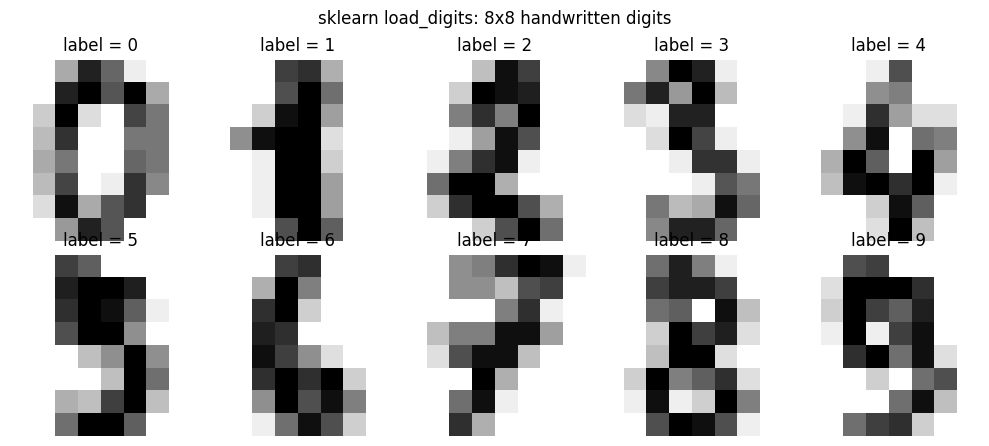


분할 결과  train: (1078, 64)  val: (359, 64)  test: (360, 64)
표준화 후 train 평균/표준편차 (전체 픽셀 기준): 0.0000 / 0.9682
표준화 후 test  평균/표준편차 (전체 픽셀 기준): -0.0036 / 0.9117   <- 정확히 0/1이 아닌 것이 정상

텐서 변환 완료: torch.Size([1078, 64]) torch.Size([1078]) torch.int64


In [ ]:
# ── 1.1 데이터 확인 & 분할 ─────────────────────────────────────

# (1) 클래스별 개수 세기 — 한쪽으로 쏠려 있는가?
print("클래스별 샘플 수:", np.bincount(y))     # TODO: 정답 배열을 넣어 클래스별 개수를 센다
print("가장 많은 클래스 / 가장 적은 클래스:", np.bincount(y).max(), "/", np.bincount(y).min())

# (2) 이미지 10장 눈으로 확인 (보일러플레이트 — 그대로 두세요)
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(f"label = {y[i]}")
    ax.axis("off")
plt.suptitle("sklearn load_digits: 8x8 handwritten digits")
plt.tight_layout()
plt.show()

# (3) train : val : test = 60 : 20 : 20 으로 두 번에 걸쳐 분할
#     stratify=... 를 주면 각 세트의 클래스 비율이 원본과 같게 유지된다.
# TODO: 먼저 전체를 train(60%) / 임시(40%)로 나눈다. random_state 는 MY_SEED.
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, random_state=MY_SEED, stratify=y
)
# TODO: 임시(40%)를 다시 반으로 갈라 val(20%) / test(20%)로 만든다.
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=MY_SEED, stratify=y_tmp
)
print("\n분할 결과  train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)

# (4) 표준화 — 평균/표준편차는 반드시 train 에서만 학습(fit)한다!
scaler = StandardScaler()
# TODO: train 에만 fit 하고, 세 세트 모두 transform 한다. (fit_transform 을 val/test 에 쓰면 누수!)
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("표준화 후 train 평균/표준편차 (전체 픽셀 기준): "
      f"{X_train_s.mean():.4f} / {X_train_s.std():.4f}")
print("표준화 후 test  평균/표준편차 (전체 픽셀 기준): "
      f"{X_test_s.mean():.4f} / {X_test_s.std():.4f}   <- 정확히 0/1이 아닌 것이 정상")

# (5) PyTorch 텐서로 변환 (실수형 X, 정수형 라벨 y)
Xtr = torch.tensor(X_train_s, dtype=torch.float32); ytr = torch.tensor(y_train, dtype=torch.long)
Xva = torch.tensor(X_val_s,   dtype=torch.float32); yva = torch.tensor(y_val,   dtype=torch.long)
Xte = torch.tensor(X_test_s,  dtype=torch.float32); yte = torch.tensor(y_test,  dtype=torch.long)
print("\n텐서 변환 완료:", Xtr.shape, ytr.shape, ytr.dtype)

**해석 질문 1.1 (본인이 출력한 실제 값을 인용해 답하세요)**

1. train / val / test 각각 몇 개의 샘플이 배정되었나요? 클래스별 개수(`np.bincount(y)`)를 보고, 이 데이터가 1주차 Framingham의 `TenYearCHD`(양성 약 15%)처럼 **불균형**한지 아닌지 판단하세요. 불균형하지 않다면, "무조건 한 클래스로만 찍는" 모델의 정확도는 몇 % 정도일까요?
train: 1,078개
validation: 359개
test: 360개
각 클래스가 174~183개 정도로 매우 비슷하다 그렇기에 1주차 과제처럼 불균형하지는 않다 가장 큰 데이터인 183으로 보면 대략 모델 정확도는 10퍼정도 나온다

2. `X_test_s`의 평균이 정확히 0이 **아닌** 이유는 무엇인가요? 만약 `scaler.fit_transform(X_test)` 로 test에도 따로 fit 했다면 평균은 0이 되었을 텐데, 그렇게 하면 **왜 안 되는지** '데이터 누수' 개념으로 설명하세요.
X_test_s의 평균이 -0.0036인 것은 train의 평균·표준편차로 test를 변환했기 때문이다. test에 따로 fit하면 test 정보를 학습에 사용하게 되어 데이터 누수가 발생한다
3. train / val / test **세 덩어리**가 필요한 이유를, 강의 p.40 **Early Stopping**과 연결해 한 문장으로 쓰세요. (힌트: 멈출 시점을 무엇으로 고르고, 최종 성적표는 무엇으로 매기는가?)
학습 중에는 validation loss를 이용해 Early Stopping할 시점을 결정하고 학습이 끝난 후에는 학습에 사용하지 않은 test 데이터로 최종 일반화 성능을 평가하기 위해 train / validation / test를 세 덩어리로 나눈다

---

### 1.2 PyTorch로 MLP 학습하기 — 미니배치 SGD 루프를 직접 채우기

§1.1에서 준비한 데이터를 이용해 이제 **PyTorch MLP를 직접 학습**합니다. 모델과 손실 함수는 PyTorch가 제공하지만, 강의 p.47의 **미니배치 SGD 4단계**는 직접 코드로 완성합니다.

> **Loop:**
> 1. **미니배치 샘플링** — 전체 학습 데이터에서 일부를 미니배치로 추출
> 2. **순전파 및 손실 계산** — 미니배치를 모델에 입력하여 예측값과 손실을 계산
> 3. **역전파** — 손실을 기준으로 각 파라미터의 기울기를 계산
> 4. **파라미터 업데이트** — 계산된 기울기의 반대 방향으로 파라미터를 업데이트

이 네 단계는 PyTorch 코드와 거의 그대로 대응됩니다.

| 강의 단계 | PyTorch 코드 |
|---|---|
| 1. 미니배치 샘플링 | `for xb, yb in loader:` (DataLoader가 대신 수행) |
| 2. 순전파 + 손실 | `loss = criterion(model(xb), yb)` |
| 3. 역전파 | `loss.backward()` |
| 4. 업데이트 | `optimizer.step()` |
| (+) 기울기 초기화 | `optimizer.zero_grad()` ← **매 스텝 맨 앞에!** |

⚠️ **`optimizer.zero_grad()`를 빠뜨리면** PyTorch는 gradient를 덮어쓰지 않고 **누적**합니다. 이전 미니배치의 기울기가 계속 더해져 학습이 의도와 다르게 진행되므로, 순서(`zero_grad → forward/loss → backward → step`)를 기억하세요.

**`nn.CrossEntropyLoss`의 주의점** — 이 함수는 내부에서 softmax와 cross entropy 계산을 함께 처리합니다. 따라서 모델의 마지막 층은 **`nn.Linear`로 끝내고 softmax를 따로 붙이지 않습니다.** softmax를 추가하면 같은 변환이 중복되어 학습 성능이 나빠질 수 있습니다.

**`model.train()` / `model.eval()`** — Dropout(§1.4)처럼 학습할 때와 평가할 때 **동작이 달라지는 층**이 있으므로 모드를 명시해야 합니다. `torch.no_grad()`는 평가 중 gradient 계산 그래프를 만들지 않아 메모리 사용량과 계산량을 줄입니다.

**이번 절의 모델 (강의 p.28 표대로):** `Input 64` → `Hidden 64 (ReLU)` → `Hidden 32 (ReLU)` → `Output 10`


In [ ]:
# ── 1.2 공용 도구: 모델 빌더 · 평가 함수 · 학습 루프 ────────────
# 여기서 만든 세 함수는 §1.3 ~ §2 에서 계속 재사용합니다.

criterion = nn.CrossEntropyLoss()   # softmax 를 내부에 포함! 모델 끝에 softmax 붙이지 말 것

def build_mlp(hidden=(64, 32), act=nn.ReLU, in_dim=64, out_dim=10, p_drop=0.0, seed=MY_SEED):
    """(입력) -> [Linear -> act -> (Dropout)] x len(hidden) -> Linear(출력) 구조의 MLP."""
    torch.manual_seed(seed)          # 초기화 재현성
    layers, prev = [], in_dim
    for hdim in hidden:
        # TODO: Linear(prev -> hdim) 과 활성화 함수 act() 를 차례로 추가하라
        layers += [nn.Linear(prev, hdim), act()]
        if p_drop > 0:
            layers.append(nn.Dropout(p_drop))
        prev = hdim
    # TODO: 마지막 출력층 (활성화 함수 없이 Linear 로 끝낸다 — CrossEntropyLoss 가 softmax 담당)
    layers.append(nn.Linear(prev, out_dim))
    return nn.Sequential(*layers)

@torch.no_grad()                     # 평가 중에는 gradient 를 만들지 않는다
def evaluate(model, X, y):
    """(loss, accuracy) 를 돌려준다."""
    # TODO: 평가 모드로 전환 (Dropout 등을 끈다)
    model.eval()
    out = model(X)
    loss = criterion(out, y).item()
    # TODO: 가장 확률이 큰 클래스를 예측으로 삼아 정확도를 구하라 (힌트: out.argmax(1))
    acc = (out.argmax(1) == y).float().mean().item()
    return loss, acc

def train_model(model, Xt=Xtr, yt=ytr, Xv=Xva, yv=yva, epochs=60,
                opt_name="adam", lr=1e-3, weight_decay=0.0, batch_size=64, seed=MY_SEED):
    """미니배치 SGD 루프. epoch 마다 train/val 의 loss·accuracy 를 기록해 돌려준다."""
    torch.manual_seed(seed)

    # ── optimizer 선택 (§1.5 에서 이 세 가지를 비교합니다) ──
    if opt_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "momentum":
        # TODO: SGD 에 momentum=0.9 를 주어 강의 p.48 의 Momentum 을 만든다
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9 , weight_decay=weight_decay)
    elif opt_name == "adam":
        # TODO: Adam optimizer 를 만든다 (lr, weight_decay 전달)
        optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay)
    else:
        raise ValueError(opt_name)

    g = torch.Generator().manual_seed(seed)          # 셔플 순서 재현
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True, generator=g)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(epochs):
        model.train()                                 # 학습 모드
        for xb, yb in loader:                         # [단계1] 미니배치 샘플링
            # TODO [+] 이전 스텝의 gradient 를 0으로 초기화
            optimizer.zero_grad()
            # TODO [단계2] 순전파 + 손실 계산
            loss = criterion(model(xb), yb)
            # TODO [단계3] 역전파 — 각 파라미터의 gradient 계산
            loss.backward()
            # TODO [단계4] gradient 반대 방향으로 파라미터 업데이트
            optimizer.step()

        tl, ta = evaluate(model, Xt, yt)
        vl, va = evaluate(model, Xv, yv)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta);  hist["val_acc"].append(va)
    return hist

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def plot_curves(hist_dict, title, metric="loss"):
    """{이름: hist} 를 받아 train(점선)/val(실선) 곡선을 겹쳐 그린다."""
    plt.figure(figsize=(7, 4.2))
    for name, h in hist_dict.items():
        line, = plt.plot(h[f"val_{metric}"], label=f"{name} (val)")
        plt.plot(h[f"train_{metric}"], linestyle="--", alpha=0.6,
                 color=line.get_color(), label=f"{name} (train)")
    plt.xlabel("epoch"); plt.ylabel(metric); plt.title(title)
    plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("도구 준비 완료:", build_mlp, evaluate, train_model, sep="\n  ")

도구 준비 완료:
  <function build_mlp at 0x78ff106af100>
  <function evaluate at 0x78ff106aefc0>
  <function train_model at 0x78ff106af060>


Sequential(
  (0): Linear(in_features=64, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=10, bias=True)
)
파라미터 수: 6570


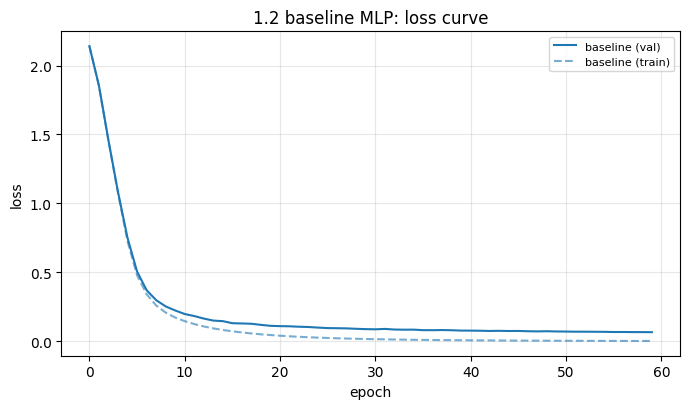

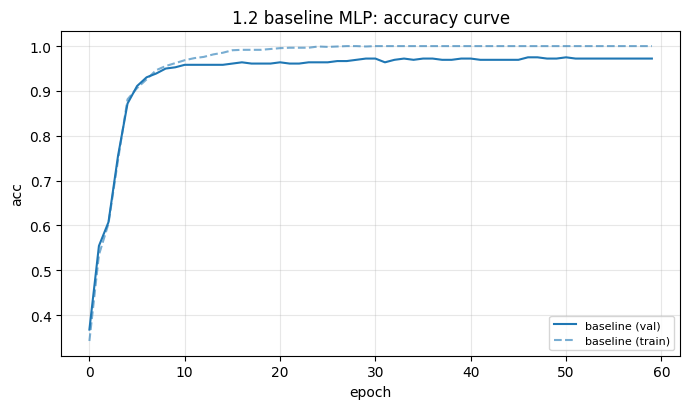


[최종] test loss = 0.0768 | test accuracy = 0.9694
val_loss 최저 epoch = 60 (val_loss = 0.0669)
마지막 epoch 의 train_loss = 0.0030 / val_loss = 0.0669
train_acc = 1.0000 / val_acc = 0.9721


In [ ]:
# ── 1.2 baseline MLP 학습: 64 -> 64 -> 32 -> 10 ────────────────
baseline = build_mlp(hidden=(64, 32), act=nn.ReLU)
print(baseline)
print("파라미터 수:", count_params(baseline))

hist_base = train_model(baseline, epochs=60, opt_name="adam", lr=1e-3)

# 학습 곡선 (강의 p.40 Early Stopping 그림과 같은 형태가 나오는지 보세요)
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: loss curve", metric="loss")
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: accuracy curve", metric="acc")

# TODO: 마지막에 딱 한 번, test 세트로 최종 성능을 측정하라
test_loss, test_acc = evaluate(baseline, Xte, yte)
print(f"\n[최종] test loss = {test_loss:.4f} | test accuracy = {test_acc:.4f}")

# TODO: val_loss 가 가장 낮았던 epoch 번호를 찾아라 (Early Stopping 이라면 여기서 멈췄을 것)
best_ep = int(np.argmin(hist_base["val_loss"])) + 1
print(f"val_loss 최저 epoch = {best_ep} (val_loss = {min(hist_base['val_loss']):.4f})")
print(f"마지막 epoch 의 train_loss = {hist_base['train_loss'][-1]:.4f} / "
      f"val_loss = {hist_base['val_loss'][-1]:.4f}")
print(f"train_acc = {hist_base['train_acc'][-1]:.4f} / val_acc = {hist_base['val_acc'][-1]:.4f}")

In [ ]:
# ── 1.2 공용 도구: 모델 빌더 · 평가 함수 · 학습 루프 ────────────
# 여기서 만든 세 함수는 §1.3 ~ §2 에서 계속 재사용합니다.

criterion = nn.CrossEntropyLoss()   # softmax 를 내부에 포함! 모델 끝에 softmax 붙이지 말 것

def build_mlp(hidden=(64, 32), act=nn.ReLU, in_dim=64, out_dim=10, p_drop=0.0, seed=MY_SEED):
    """(입력) -> [Linear -> act -> (Dropout)] x len(hidden) -> Linear(출력) 구조의 MLP."""
    torch.manual_seed(seed)          # 초기화 재현성
    layers, prev = [], in_dim
    for hdim in hidden:
        # TODO: Linear(prev -> hdim) 과 활성화 함수 act() 를 차례로 추가하라
        layers += [nn.Linear(prev, hdim), act()]
        if p_drop > 0:
            layers.append(nn.Dropout(p_drop))
        prev = hdim
    # TODO: 마지막 출력층 (활성화 함수 없이 Linear 로 끝낸다 — CrossEntropyLoss 가 softmax 담당)
    layers.append(nn.Linear(prev, out_dim))
    return nn.Sequential(*layers)

@torch.no_grad()                     # 평가 중에는 gradient 를 만들지 않는다
def evaluate(model, X, y):
    """(loss, accuracy) 를 돌려준다."""
    # TODO: 평가 모드로 전환 (Dropout 등을 끈다)
    model.eval()
    out = model(X)
    loss = criterion(out, y).item()
    # TODO: 가장 확률이 큰 클래스를 예측으로 삼아 정확도를 구하라 (힌트: out.argmax(1))
    acc = (out.argmax(1) == y).float().mean().item()
    return loss, acc

def train_model(model, Xt=Xtr, yt=ytr, Xv=Xva, yv=yva, epochs=60,
                opt_name="adam", lr=1e-3, weight_decay=0.0, batch_size=64, seed=MY_SEED):
    """미니배치 SGD 루프. epoch 마다 train/val 의 loss·accuracy 를 기록해 돌려준다."""
    torch.manual_seed(seed)

    # ── optimizer 선택 (§1.5 에서 이 세 가지를 비교합니다) ──
    if opt_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "momentum":
        # TODO: SGD 에 momentum=0.9 를 주어 강의 p.48 의 Momentum 을 만든다
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9 , weight_decay=weight_decay)
    elif opt_name == "adam":
        # TODO: Adam optimizer 를 만든다 (lr, weight_decay 전달)
        optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay)
    else:
        raise ValueError(opt_name)

    g = torch.Generator().manual_seed(seed)          # 셔플 순서 재현
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True, generator=g)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(epochs):
        model.train()                                 # 학습 모드
        for xb, yb in loader:                         # [단계1] 미니배치 샘플링

            # TODO [단계2] 순전파 + 손실 계산
            loss = criterion(model(xb), yb)
            # TODO [단계3] 역전파 — 각 파라미터의 gradient 계산
            loss.backward()
            # TODO [단계4] gradient 반대 방향으로 파라미터 업데이트
            optimizer.step()

        tl, ta = evaluate(model, Xt, yt)
        vl, va = evaluate(model, Xv, yv)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta);  hist["val_acc"].append(va)
    return hist

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def plot_curves(hist_dict, title, metric="loss"):
    """{이름: hist} 를 받아 train(점선)/val(실선) 곡선을 겹쳐 그린다."""
    plt.figure(figsize=(7, 4.2))
    for name, h in hist_dict.items():
        line, = plt.plot(h[f"val_{metric}"], label=f"{name} (val)")
        plt.plot(h[f"train_{metric}"], linestyle="--", alpha=0.6,
                 color=line.get_color(), label=f"{name} (train)")
    plt.xlabel("epoch"); plt.ylabel(metric); plt.title(title)
    plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("도구 준비 완료:", build_mlp, evaluate, train_model, sep="\n  ")

도구 준비 완료:
  <function build_mlp at 0x78ff0bad5300>
  <function evaluate at 0x78ff0bad6020>
  <function train_model at 0x78ff106af560>


Sequential(
  (0): Linear(in_features=64, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=10, bias=True)
)
파라미터 수: 6570


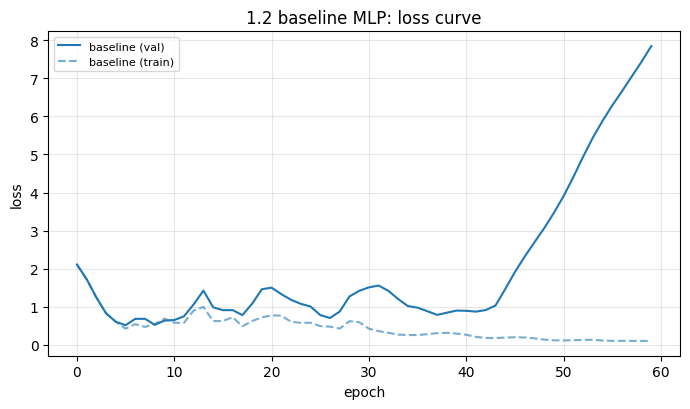

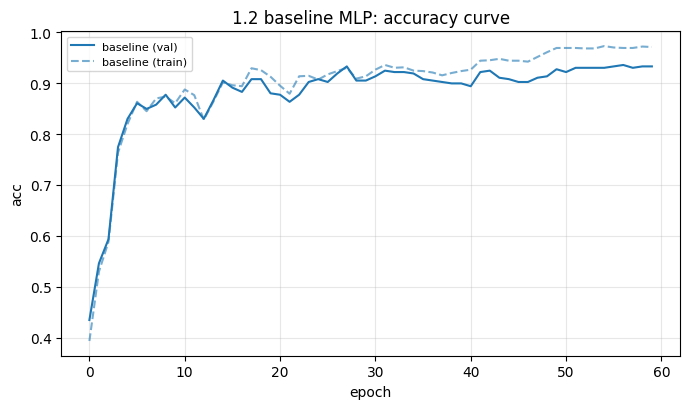


[최종] test loss = 1.7360 | test accuracy = 0.9389
val_loss 최저 epoch = 6 (val_loss = 0.5107)
마지막 epoch 의 train_loss = 0.0984 / val_loss = 7.8509
train_acc = 0.9712 / val_acc = 0.9331


In [ ]:
# ── 1.2 baseline MLP 학습: 64 -> 64 -> 32 -> 10 ────────────────
baseline = build_mlp(hidden=(64, 32), act=nn.ReLU)
print(baseline)
print("파라미터 수:", count_params(baseline))

hist_base = train_model(baseline, epochs=60, opt_name="adam", lr=1e-3)

# 학습 곡선 (강의 p.40 Early Stopping 그림과 같은 형태가 나오는지 보세요)
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: loss curve", metric="loss")
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: accuracy curve", metric="acc")

# TODO: 마지막에 딱 한 번, test 세트로 최종 성능을 측정하라
test_loss, test_acc = evaluate(baseline, Xte, yte)
print(f"\n[최종] test loss = {test_loss:.4f} | test accuracy = {test_acc:.4f}")

# TODO: val_loss 가 가장 낮았던 epoch 번호를 찾아라 (Early Stopping 이라면 여기서 멈췄을 것)
best_ep = int(np.argmin(hist_base["val_loss"])) + 1
print(f"val_loss 최저 epoch = {best_ep} (val_loss = {min(hist_base['val_loss']):.4f})")
print(f"마지막 epoch 의 train_loss = {hist_base['train_loss'][-1]:.4f} / "
      f"val_loss = {hist_base['val_loss'][-1]:.4f}")
print(f"train_acc = {hist_base['train_acc'][-1]:.4f} / val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.2 (본인 출력값 인용)**

1. 이 모델의 **파라미터 수**는 몇 개인가요? 손으로도 계산해 확인하세요: $64{\times}64+64$, $64{\times}32+32$, $32{\times}10+10$ 의 합과 같은가요? (bias를 빠뜨리지 마세요.)6570개

2. 본인의 **test accuracy**를 적으세요. §1.1에서 계산한 "무조건 한 클래스로 찍기" 정확도와 비교하면 얼마나 나은가요? 0.9694 10퍼보다 훨씬 한 86퍼정도 높다

3. **loss 곡선을 보세요.** train loss는 계속 내려가는데 val loss는 어느 지점부터 더 내려가지 않거나 **살짝 올라가기 시작**했을 것입니다. 그 지점(대략 몇 epoch)과, 그때 train/val loss 값을 적으세요. 이 그림이 강의 p.40 Early Stopping 슬라이드의 그림과 어떻게 대응되는지 설명하세요. 음 제 loss 곡선에서는 살짝 올라가기 시작하는 부분이 보이지않아서 Early Stopping이 필요한 시점이 나타나지 않았지않았다

4. `optimizer.zero_grad()` 를 **일부러 지우고** 다시 실행해 보세요(다른 셀에 복사해서 실험할 것). 학습 곡선이 어떻게 달라졌나요? PyTorch가 gradient를 **누적**한다는 사실과 연결해 설명하세요.
zero_grad()를 제거하자 train loss는 계속 감소하지만 val loss가 크게 진동하고 약 40 epoch 이후 급격히 증가하여 학습이 불안정해졌다. 이는 PyTorch가 이전 미니배치 gradient를 초기화하지 않고 계속 누적하기 때문에 학습곡선이 달라졌다
5. 모델 마지막에 `nn.Softmax(dim=1)` 을 추가하면 어떻게 될지 예상하고, 실제로 추가해 성능을 비교해 보세요. (힌트: `nn.CrossEntropyLoss`는 이미 softmax를 품고 있습니다.)

---

### 1.3 Issue 1) Vanishing Gradient — 강의의 주장을 gradient로 직접 재기

강의 4장은 "Deep architecture는 input에서 output까지 gradient chain이 길어서 **Vanishing Gradient**가 생기고, 처방은 **non-saturating 활성화 함수(ReLU 계열)**"라고 말합니다(p.37~38). 여기서는 그 말을 **숫자로 확인**합니다.

**실험 설계**

- 은닉층 **8개**(width 32)를 쌓은 깊은 MLP를 두 개 만듭니다. **딱 하나만 다릅니다: 활성화 함수가 Sigmoid냐 ReLU냐.**
- 아직 **학습은 하지 않고**, 초기 파라미터에서 **역전파를 딱 한 번** 돌립니다.
- 그리고 **각 층 가중치의 gradient 크기(L2 norm)** 를 재서, 출력층에서 입력층으로 갈수록 얼마나 작아지는지 봅니다.
- 마지막으로 두 네트워크를 실제로 40 epoch 학습시켜 **성능 차이**를 확인합니다.

**왜 gradient의 norm인가?** gradient가 0에 가깝다는 것은 "이 층의 가중치를 아무리 바꿔도 loss가 거의 안 변한다 → **업데이트 신호가 없다 → 학습이 안 된다**"는 뜻입니다. Sigmoid를 한 번 지날 때마다 도함수 $h(1-h) \le 0.25$가 곱해지므로, 층이 깊어질수록 앞쪽 층의 gradient는 기하급수적으로 줄어듭니다.

> 📌 **이 절의 결과가 강의 마지막 서술형 퀴즈의 답입니다.** 그래프를 캡처해 기술블로그에 넣고, "chain rule 관점에서 왜 사라지는가"를 본인 숫자로 설명하세요.

층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층

[Sigmoid]  1.40e-07 3.24e-07 2.21e-06 1.62e-05 1.17e-04 9.19e-04 5.38e-03 3.97e-02 2.59e-01
[ReLU]     5.29e-04 4.74e-04 4.71e-04 4.88e-04 1.02e-03 1.31e-03 2.97e-03 5.00e-03 2.02e-02

Sigmoid: 마지막층 / 첫번째층 = 1.855e+06 배
ReLU   : 마지막층 / 첫번째층 = 3.812e+01 배


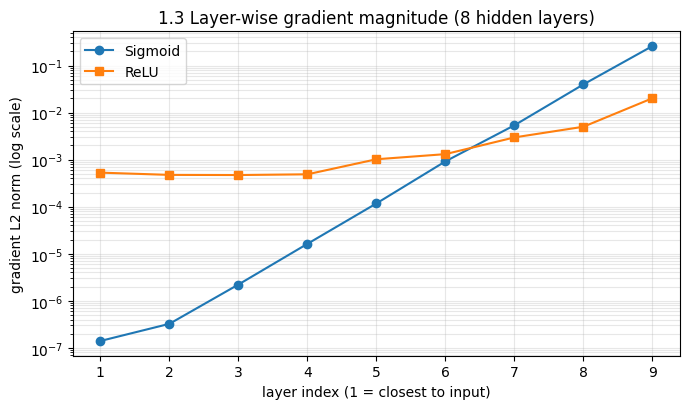

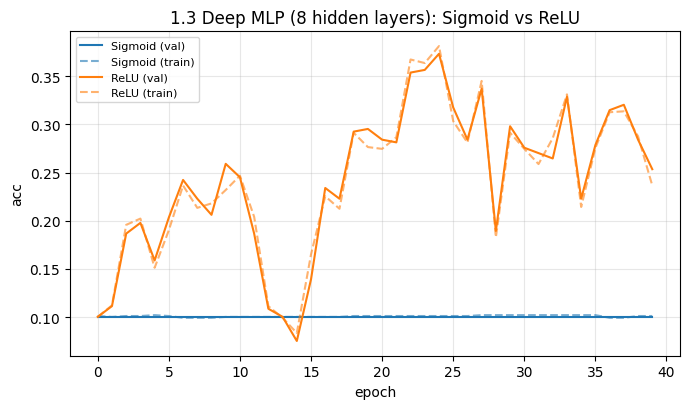


[Sigmoid 8층] 최종 train_acc = 0.1011 / val_acc = 0.1003
[ReLU    8층] 최종 train_acc = 0.2365 / val_acc = 0.2535
[참고: 1.2 얕은 2층 ReLU] val_acc = 0.9331


In [ ]:
# ── 1.3 Vanishing Gradient 측정 ────────────────────────────────

def build_deep(act, depth=8, width=32, seed=MY_SEED):
    """은닉층을 depth 개 쌓은 깊은 MLP. act 만 바꿔 가며 비교한다."""
    torch.manual_seed(seed)
    layers, prev = [], 64
    for _ in range(depth):
        layers += [nn.Linear(prev, width), act()]
        prev = width
    layers.append(nn.Linear(prev, 10))
    return nn.Sequential(*layers)

def layerwise_grad_norms(model, X, y):
    """역전파를 한 번 돌리고, 각 Linear 층 weight 의 gradient L2 norm 을 리스트로 돌려준다."""
    model.train()
    model.zero_grad()
    loss = criterion(model(X), y)
    # TODO: 역전파를 수행해 각 파라미터의 .grad 를 채워라
    loss.backward()
    norms = []
    for name, param in model.named_parameters():
        if name.endswith("weight"):
            # TODO: 이 층 gradient 의 L2 norm 을 float 로 담아라 (힌트: param.grad.norm().item())
            norms.append(param.grad.norm().item())
    return norms

# (1) 활성화 함수만 바꾼 두 깊은 네트워크의 층별 gradient 크기 비교
# TODO: 각각 nn.Sigmoid / nn.ReLU 를 넣어라 (클래스 자체를 넘긴다, 괄호 없이!)
deep_sig  = build_deep(act=nn.Sigmoid)
deep_relu = build_deep(act=nn.ReLU)

norms_sig  = layerwise_grad_norms(deep_sig,  Xtr, ytr)
norms_relu = layerwise_grad_norms(deep_relu, Xtr, ytr)

print("층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층\n")
print("[Sigmoid] ", " ".join(f"{v:.2e}" for v in norms_sig))
print("[ReLU]    ", " ".join(f"{v:.2e}" for v in norms_relu))
print(f"\nSigmoid: 마지막층 / 첫번째층 = {norms_sig[-1] / norms_sig[0]:.3e} 배")
print(f"ReLU   : 마지막층 / 첫번째층 = {norms_relu[-1] / norms_relu[0]:.3e} 배")

# (2) 층별 gradient 크기 그래프 (y축은 log scale 이어야 차이가 보인다)
plt.figure(figsize=(7, 4.2))
layer_idx = np.arange(1, len(norms_sig) + 1)
plt.semilogy(layer_idx, norms_sig,  "o-", label="Sigmoid")
plt.semilogy(layer_idx, norms_relu, "s-", label="ReLU")
plt.xlabel("layer index (1 = closest to input)")
plt.ylabel("gradient L2 norm (log scale)")
plt.title("1.3 Layer-wise gradient magnitude (8 hidden layers)")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

# (3) 실제로 학습시켜 성능 차이 확인 (40 epoch)
hist_sig  = train_model(build_deep(act=nn.Sigmoid), epochs=40)
hist_relu = train_model(build_deep(act=nn.ReLU),    epochs=40)
plot_curves({"Sigmoid": hist_sig, "ReLU": hist_relu},
            "1.3 Deep MLP (8 hidden layers): Sigmoid vs ReLU", metric="acc")

print(f"\n[Sigmoid 8층] 최종 train_acc = {hist_sig['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_sig['val_acc'][-1]:.4f}")
print(f"[ReLU    8층] 최종 train_acc = {hist_relu['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_relu['val_acc'][-1]:.4f}")
print(f"[참고: 1.2 얕은 2층 ReLU] val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.3 (본인 출력값 인용)**

1. **Sigmoid 네트워크의 첫 번째 층과 마지막 층의 gradient norm**을 적고, 몇 배 차이인지 쓰세요. ReLU는 몇 배였나요? 두 배율을 나란히 비교해 한 문장으로 결론지으세요.
Sigmoid은 첫 층 1.40e-07, 마지막 층 2.59e-01로 약 1.855e+06배 차이가 났고, ReLU는 첫 층 5.29e-04, 마지막 층 2.02e-02로 약 3.812e+01배 차이가 났다. Sigmoid에서 gradient가 훨씬 심하게 소실되었다

2. Sigmoid의 도함수 $\sigma'(z) = h(1-h) \le 0.25$ 를 이용해, **왜 Sigmoid에서만 이런 일이 생기는지** chain rule 식으로 설명하세요. ReLU의 도함수는 양수 구간에서 얼마인가요? 그래서 어떻게 되나요?
Sigmoid는 여러 층을 거치면서 도함수 σ′z가 최대 0.25인 값이 계속 곱해지기 때문에 깊어질수록 gradient가 급격히 작아진다 반면 ReLU는 양수 구간에서 도함수가 1이므로 gradient가 크게 감소하지 않는다

3. 학습 결과: Sigmoid 8층과 ReLU 8층의 최종 **train accuracy**를 적으세요. Sigmoid 쪽은 **train accuracy조차** 낮게 나왔을 것입니다. 이것이 과적합(overfitting) 문제와는 **완전히 다른 종류의 실패**인 이유를 설명하세요. (힌트: 과적합은 "train은 잘하는데 val이 나쁜" 것입니다.) Sigmoid 8층의 train accuracy는 10.11%, ReLU 8층은 23.65%였다. Sigmoid는 train 데이터조차 제대로 학습하지 못했기 때문에 과적합이 아니라 vanishing gradient로 인한 학습 실패에 해당한다

4. §1.2의 **얕은(2층) ReLU** 모델의 val accuracy와 §1.3의 **깊은(8층) ReLU** 모델을 비교하세요. 층을 4배로 늘렸는데 성능이 좋아졌나요? 예상과 다르다면 그 원인으로 무엇을 의심하겠습니까? (§2-B에서 이어서 다룹니다.)
얕은 2층 ReLU의 val accuracy는 93.31%, 깊은 8층 ReLU는 25.35%로 오히려 크게 낮아졌다. 따라서 층을 깊게 쌓는다고 항상 성능이 좋아지는 것은 아니며 최적화나 초기화, 학습률 등의 문제를 의심할 수 있다
5. **강의 서술형 퀴즈에 답하세요.** "Sigmoid를 hidden layer의 활성화 함수로 사용한 DNN에서 vanishing gradient가 발생하는 이유를 backpropagation의 chain rule 관점에서 설명하고, 이를 해결하는 방법을 **2가지 이상** 제시하시오." — 본인이 방금 잰 숫자를 근거로 인용해서 답하세요.
Sigmoid는 backpropagation에서 여러 층의 도함수가 연속해서 곱해지면서 gradient가 급격히 작아진다. 실제로 첫 층 gradient는 1.40e-07까지 감소한 반면 마지막 층은 2.59e-01이었다. 해결 방법으로 ReLU 같은 활성화 함수 사용, Batch Normalization 등을 사용할 수 있다

---

### 1.4 Issue 2) Overfitting — 네 가지 처방을 같은 조건에서 붙여 보기

강의 p.39는 과적합을 "Training error는 줄지만 Generalization 성능은 낮음 / **노이즈까지 기억하는** 상태"로 정의하고, 처방 네 가지를 제시했습니다.

| Remedy | 아이디어 | 이번 실험에서 |
|---|---|---|
| ① **Early Stopping** | val loss가 개선되지 않으면 중단 | `val_loss` 최저 epoch를 찾아 "여기서 멈췄어야 했다"를 확인 |
| ② **Data Augmentation** | label을 유지하는 노이즈 데이터로 robustness 향상 | (심화 §2-C에서 도전 가능) |
| ③ **L1/L2 Regularization** | `Loss = error + 모델 크기` | `weight_decay` 로 L2 적용, 강도 2단계 비교 |
| ④ **Dropout** | 매 스텝 유닛을 확률적으로 비활성화 | `p_drop=0.5` (강의 권장값: hidden 50%) |

**과적합을 일부러 만듭니다.** §1.2의 모델은 데이터가 충분해 과적합이 약했습니다. 그래서 이번엔 **훈련 데이터를 150개로 줄이고**(전체의 약 14%) 모델을 **256-256으로 키워** 극단적인 상황을 만듭니다. 데이터는 적고 파라미터는 많으니 모델이 150개를 통째로 외워 버리기 좋은 조건입니다.

**공정 비교의 원칙:** 네 조건에서 **바뀌는 것은 규제 하나뿐**이고 데이터·구조·시드·epoch 수는 모두 동일합니다. 그래야 차이의 원인을 규제로 돌릴 수 있습니다.

⚠️ **Dropout 주의:** `model.train()`일 때만 뉴런을 끄고, `model.eval()`에서는 모두 켠 채 스케일을 보정합니다(강의 p.43: "추론 시 출력에 p를 곱해 기댓값을 맞춘다"). §1.2에서 `evaluate()` 안에 `model.eval()`을 넣은 이유가 바로 이것입니다 — 빠뜨리면 평가할 때마다 결과가 달라집니다.

작은 훈련셋: torch.Size([150, 64]) | 원래 훈련셋: torch.Size([1078, 64])


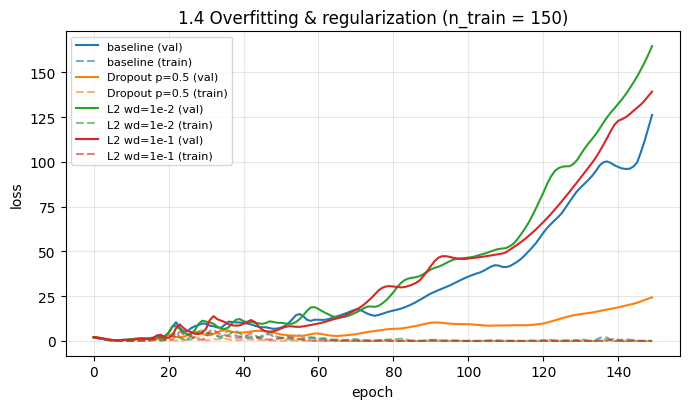

조건               train_loss  val_loss     gap  train_acc  val_acc  best_ep best_val_acc
----------------------------------------------------------------------------------------
baseline             0.0000  126.2939126.2939     1.0000   0.8301        6       0.9053
Dropout p=0.5        0.0000   24.3513 24.3513     1.0000   0.9081        8       0.9331
L2 wd=1e-2           0.0000  164.7548164.7548     1.0000   0.8524        7       0.9025
L2 wd=1e-1           0.0062  139.3172139.3110     0.9933   0.8412        7       0.9025

[Early Stopping] baseline 은 epoch 6 에서 멈췄어야 했다. (실제로는 150 까지 돌렸으니 144 epoch 를 낭비)


In [ ]:
# ── 1.4 과적합 만들고, 규제 네 가지 비교 ────────────────────────

# (1) 훈련 데이터를 150개로 줄여 과적합 상황을 만든다
rng = np.random.default_rng(MY_SEED)
# TODO: 훈련셋 인덱스 중 150개를 비복원추출하라 (힌트: rng.choice(len(Xtr), size=..., replace=False))
small_idx = rng.choice(len(Xtr), size=150, replace=False)
Xsm, ysm = Xtr[small_idx], ytr[small_idx]
print("작은 훈련셋:", Xsm.shape, "| 원래 훈련셋:", Xtr.shape)

# (2) 규제만 바꿔 가며 동일 조건으로 학습
#     (모델은 모두 64 -> 256 -> 256 -> 10, epochs=150, batch_size=32)
configs = [
    # (이름,            dropout 확률, L2 강도(weight_decay))
    ("baseline",        0.0,  0.0),
    ("Dropout p=0.5",   0.5,  0.0),
    ("L2 wd=1e-2",      0.0,  1e-2),
    ("L2 wd=1e-1",      0.0,  1e-1),
]

hist14 = {}
for name, p_drop, wd in configs:
    # TODO: hidden=(256, 256) 이고 dropout 확률이 p_drop 인 모델을 만들어라
    m = build_mlp(hidden=(256, 256), p_drop=p_drop)
    # TODO: 작은 훈련셋(Xsm, ysm)으로 150 epoch 학습. weight_decay 에 wd 를 전달할 것.
    hist14[name] = train_model(m, Xt=Xsm, yt=ysm, epochs=150,
                               weight_decay=wd, batch_size=32)

plot_curves(hist14, "1.4 Overfitting & regularization (n_train = 150)", metric="loss")

# (3) 요약표 — 과적합 정도(gap)와 Early Stopping 시점
print(f"{'조건':<16}{'train_loss':>11}{'val_loss':>10}{'gap':>8}"
      f"{'train_acc':>11}{'val_acc':>9}{'best_ep':>9}{'best_val_acc':>13}")
print("-" * 88)
for name, h in hist14.items():
    tl, vl = h["train_loss"][-1], h["val_loss"][-1]
    # TODO: val_loss 가 최소인 epoch (0-based index) 를 찾아라 -> Early Stopping 시점
    best = int(np.argmin(h["val_loss"]))
    print(f"{name:<16}{tl:>11.4f}{vl:>10.4f}{vl - tl:>8.4f}"
          f"{h['train_acc'][-1]:>11.4f}{h['val_acc'][-1]:>9.4f}"
          f"{best + 1:>9}{max(h['val_acc']):>13.4f}")

# (4) Early Stopping 을 썼다면 몇 epoch 를 아꼈을까?
best_base = int(np.argmin(hist14["baseline"]["val_loss"])) + 1
print(f"\n[Early Stopping] baseline 은 epoch {best_base} 에서 멈췄어야 했다. "
      f"(실제로는 150 까지 돌렸으니 {150 - best_base} epoch 를 낭비)")

**해석 질문 1.4 (본인 출력값 인용)**

1. **baseline이 과적합했다는 증거**를 세 가지 숫자로 대세요: 마지막 `train_loss`, `train_acc`, 그리고 `val_loss - train_loss` (gap). 강의 p.39의 정의("Training error는 줄지만 Generalization 성능은 낮음")와 대응시켜 한 문장으로 쓰세요.
baseline의 마지막 train_loss는 0.0000 train_acc는 1.0000 val_loss - train_loss` (gap)은 126.2939이다. Training error는 거의 0으로 줄었지만 validation 성능이 나빠져 과적합이 발생했다고 볼 수 있다

2. `val_loss`가 최소였던 epoch는 baseline에서 몇이었나요? 전체 150 epoch 중 **몇 %** 지점인가요? Early Stopping이 왜 "**공짜에 가까운** 규제"라 불리는지(추가 파라미터도, 구조 변경도 없음) 본인 숫자로 설명하세요.
 baseline의 val_loss 최소 epoch는 6 epoch로, 전체 150 epoch의 4퍼 지점이다. 추가 파라미터나 구조 변경 없이 학습을 일찍 멈추기 때문에 Early Stopping은 공짜에 가까운 규제라고 할 수 있다

3. **Dropout p=0.5의 결과를 정직하게 보고하세요.** 최종 `val_loss`는 baseline보다 좋아졌나요, 나빠졌나요? 반대로 `best_val_acc`는 어땠나요? **두 지표가 다른 방향을 가리킨다면** 그 이유를 추론해 보세요. (힌트: 정확도는 "맞힌 개수", loss는 "확신의 정확성"을 잽니다.)Dropout p=0.5        0.0000   24.3513 24.3513     1.0000   0.9081        8       0.9331 Dropout p=0.5의 최종 val_loss는 24.3513으로 baseline의 126.2939보다 좋아졌고 best_val_acc도 0.9331로 baseline의 0.9053보다 높았다 Dropout이 과적합을 줄여 전반적인 일반화 성능을 개선한 결과로 볼 수 있다

4. **L2 강도를 10배로 키운 `wd=1e-1`** 에서는 무슨 일이 일어났나요? `train_acc`와 `val_acc`를 함께 보고, 이것이 과적합인지 **과소적합(underfitting)** 인지 판정하세요. "규제는 세게 걸수록 좋다"는 말이 왜 틀렸는지 본인 숫자로 반박하세요.
L2 wd=1e-1의 train_acc는 0.9933 val_acc는 0.8412로 train 성능은 매우 높지만 val 성능이 train에 비해서 낮아 과적합에 가깝다 따라서 규제는 무조건 강하게 걸수록 좋은 것이 아니라 적절한 강도를 선택해야 한다

5. 네 조건 중 **본인 데이터에서 가장 좋았던 것**은 무엇인가요? 그 결과가 강의 슬라이드의 서술과 일치했나요, 어긋났나요? 어긋났다면 원인으로 무엇을 의심하겠습니까? (힌트: 훈련 샘플 150개에 뉴런의 절반을 끄면 어떻게 될까요?)
내 데이터에서는 Dropout p=0.5가 best_val_acc 0.9331로 가장 좋았다 p.47에서 설명한 것처럼 Dropout은 학습 중 유닛을 확률적으로 비활성화하여 특정 뉴런 조합의 co-adaptation을 방지하므로 과적합을 줄이는 데 도움이 된다 다만 이번 실험은 훈련 데이터가 150개로 매우 적기 때문에 Dropout으로 뉴런의 절반을 끄는 것이 항상 유리하지 않을 수 있다

---

### 1.5 Issue 3) Optimization — SGD / Momentum / Adam을 같은 출발선에서

강의 p.45~50은 optimizer의 계보를 보여 줬습니다.

$$\text{GD} \to \text{SGD(minibatch)} \to \text{Momentum},\ \text{RMSProp} \to \text{Adam}$$

- **Mini-batch SGD**: 전체가 아닌 일부로 gradient를 계산해 **자주** 업데이트
- **Momentum**: `업데이트 = 현재 gradient + 과거 gradient` — 방향이 자주 바뀌는 축은 상쇄, 일관된 축은 가속 → 지그재그 완화, 안장점 탈출
- **Adaptive (AdaGrad → RMSProp)**: gradient가 컸던 파라미터는 학습률을 줄이고 작았던 파라미터는 키움
- **Adam**: Momentum(**방향**) + RMSProp(**크기**) = "어디로 + 얼마나"

**실험 설계** — 모델·데이터·시드·epoch를 완전히 고정하고 **optimizer만** 바꿉니다. 학습률이 optimizer마다 적정 범위가 다르므로, SGD 계열은 `lr=0.05`, Adam은 관례적 기본값 `lr=0.001`을 씁니다. 여기에 **일부러 학습률을 크게 준 `SGD lr=3.0`** 도 넣어 무슨 일이 벌어지는지 봅니다.

비교 지표는 두 가지입니다: **① 최종 성능**(어디까지 갔나)과 **② 수렴 속도**(val accuracy 90%에 몇 epoch만에 도달했나).

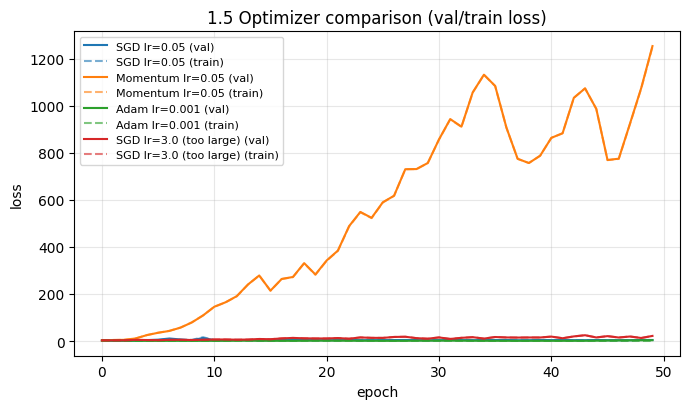

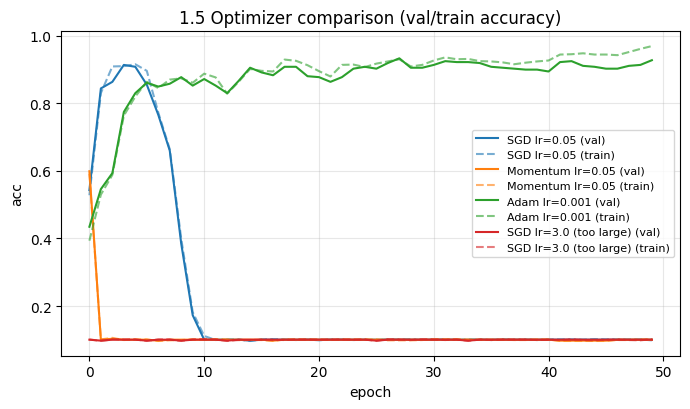

optimizer            ep1 val_loss  final train_loss  final val_acc  best val_acc  first ep >= 90%
-------------------------------------------------------------------------------------------------
SGD lr=0.05                1.7021            4.2585         0.1003        0.9136                4
Momentum lr=0.05           2.0595         1251.4900         0.1003        0.5989             None
Adam lr=0.001              2.1078            0.1123         0.9276        0.9331               15
SGD lr=3.0 (too large)       2.7472           21.6755         0.1003        0.1003             None


In [ ]:
# ── 1.5 Optimizer 비교 ─────────────────────────────────────────
opt_configs = [
    # (이름,               opt_name,     learning rate)
    ("SGD lr=0.05",        "sgd",        0.05),
    ("Momentum lr=0.05",   "momentum",   0.05),
    ("Adam lr=0.001",      "adam",       1e-3),
    ("SGD lr=3.0 (too large)",  "sgd",        3.0),
]

hist15 = {}
for name, opt_name, lr in opt_configs:
    # TODO: 모든 조건에서 동일한 구조 (64, 32) 의 모델을 새로 만들어라
    #       (같은 모델 객체를 재사용하면 앞 실험의 학습 결과가 남아 비교가 무의미해진다!)
    m = build_mlp(hidden=(64, 32))
    # TODO: opt_name 과 lr 을 전달해 50 epoch 학습
    hist15[name] = train_model(m, epochs=50, opt_name=opt_name, lr=lr)

plot_curves(hist15, "1.5 Optimizer comparison (val/train loss)", metric="loss")
plot_curves(hist15, "1.5 Optimizer comparison (val/train accuracy)", metric="acc")

# 수렴 속도: val accuracy 가 처음으로 90% 를 넘은 epoch
print(f"{'optimizer':<20}{'ep1 val_loss':>13}{'final train_loss':>18}"
      f"{'final val_acc':>15}{'best val_acc':>14}{'first ep >= 90%':>17}")
print("-" * 97)
for name, h in hist15.items():
    # TODO: val_acc 가 처음으로 0.90 이상이 되는 epoch 번호를 찾아라 (없으면 None)
    first90 = next((i + 1 for i, v in enumerate(h["val_acc"]) if v >= 0.90), None)
    print(f"{name:<20}{h['val_loss'][0]:>13.4f}{h['train_loss'][-1]:>18.4f}"
          f"{h['val_acc'][-1]:>15.4f}{max(h['val_acc']):>14.4f}{str(first90):>17}")

**해석 질문 1.5 (본인 출력값 인용)**

1. **SGD / Momentum / Adam이 val accuracy 90%에 도달한 epoch**를 각각 적으세요. Momentum이 순수 SGD보다 빠른 이유를, 강의 p.48의 "**방향이 자주 바뀌는 움직임은 줄이고, 계속 같은 방향으로 이동할 때는 속도를 높인다**"로 설명하세요.
SGD는 4 epoch Momentum은 90%에 도달하지 못해 None Adam은 15 epoch에 90%에 도달했다 강의 p.51처럼 Momentum은 현재 gradient에 과거 gradient를 누적하여 방향이 자주 바뀌는 움직임은 줄이고 같은 방향의 움직임은 가속하기 때문에 지그재그를 줄일 수 있다(51p가 관련내용인거같아서 참고해서 적었스빈다)
2. **최종 val accuracy**는 셋이 얼마나 차이 났나요? "수렴이 빠르다"와 "최종 성능이 좋다"가 같은 말인지 본인 숫자로 판단하세요.
최종 val accuracy는 SGD 0.1003, Momentum 0.1003, Adam 0.9276이었다. 따라서 수렴이 빠른 SGD가 최종 성능도 좋은 것은 아니며, 이번 실험에서는 Adam이 가장 안정적으로 높은 성능을 냈다

3. **`SGD lr=3.0`** 에서 무슨 일이 일어났나요? `val_loss` 값을 적고, 그 값이 $\ln(10) \approx 2.303$ 에 가까운 것이 무엇을 의미하는지 생각해 보세요. (힌트: 10개 클래스에 균등 확률을 주는 모델의 cross entropy는 얼마일까요?)
SGD lr=3.0은 학습이 제대로 되지 않아 최종 train loss가 21.6755, val accuracy가 0.1003에 머물렀다 첫 epoch의 val loss 2.7472는 ln(10)≈2.303보다 크므로 10개 클래스에 거의 균등한 확률을 주는 수준의 예측보다도 좋지 않은 상태라고 볼 수 있다

4. 강의 객관식 퀴즈의 보기 ①과 ⑥은 **틀린 설명**입니다. 각각 어디가 틀렸는지 고쳐 쓰세요.
   - ① "미니배치 SGD는 full-batch GD에 비해 한 epoch당 파라미터 업데이트 횟수가 줄어드는 대신, 각 업데이트에서 계산되는 gradient 추정치가 더 정확하다."
   - ⑥ "RMSProp의 decay rate $\rho$를 0에 가깝게 설정할수록 과거 gradient의 영향이 오래 유지되어 AdaGrad와 유사하게 동작한다."
   미니배치 SGD는 full-batch보다 한 epoch당 업데이트 횟수는 많아지고, 각 gradient는 일부 데이터만 사용하므로 더 부정확하지만 빠르게 업데이트할 수 있다
   RMSProp은 최근 gradient에 더 큰 비중을 주고 오래된 gradient의 영향은 감소시키므로, decay rate ρ가 0에 가까울수록 과거 gradient의 영향이 오래 유지되는 것이 아니다

5. Adam은 **Momentum(방향) + RMSProp(크기)** 라고 배웠습니다. 위 실험에서 Adam이 SGD보다 훨씬 작은 학습률(0.001 vs 0.05)을 쓰고도 더 빨리 수렴한 이유를, "파라미터마다 학습률을 다르게 준다"는 성질과 연결해 설명하세요.
Adam은 강의 p.53처럼 Momentum의 방향 정보와 RMSProp의 크기 정보를 함께 사용하므로, 파라미터마다 업데이트 크기를 조절할 수 있다 따라서 SGD의 0.05보다 작은 0.001의 학습률을 사용했음에도 필요한 파라미터는 상대적으로 크게 많이 움직인 파라미터는 작게 업데이트하여 15 epoch 만에 90%를 넘고 최종 val accuracy 0.9276을 얻었다

---

# 2. 심화 과제 — 스스로 생각하기

여기까지는 "돌리면 나오는" 영역이었습니다. 진짜 실력은 **그 값을 어떻게 읽고 판단하느냐**에서 갈립니다.
아래 세 문제는 모두 **강의 슬라이드가 주장한 것을 본인 실험으로 검증하거나 반증**하는 구조입니다. 슬라이드와 다른 결과가 나오면 **그대로 쓰고 원인을 추론**하세요.

---

### 2-A. 활성화 함수를 없애면? — "층을 쌓아도 선형"임을 직접 증명

강의 p.21은 이렇게 묻고 답했습니다.

> **Q. Why neural networks use Activation Functions?**
> **A. To introduce non-linearities into the network**

강의에서 수식으로 설명한 주장을 이제 **실험으로 확인**합니다. 활성화 함수 자리에 `nn.Identity()`(아무것도 안 하는 층)를 넣어 **은닉층이 2개인데도 사실은 선형 모델**인 네트워크를 만들고, 세 가지를 비교합니다.

| 모델 | 구조 | 파라미터 수 |
|---|---|---|
| **linear-deep** | 64 → 64 → 32 → 10, 활성화 **없음** | 6,570 |
| **single Linear** | 64 → 10, 은닉층 자체가 없음 | 650 |
| **ReLU MLP** (§1.2) | 64 → 64 → 32 → 10, ReLU | 6,570 |

그리고 **결정적 증거**로, linear-deep의 가중치 행렬 세 개를 곱해 **하나의 $10\times64$ 행렬로 접은 뒤**, 그 단일 선형변환이 원래 네트워크와 **똑같은 출력**을 내는지 확인합니다.

$$
W_{\text{eq}} = W^{(3)}W^{(2)}W^{(1)}, \qquad
b_{\text{eq}} = W^{(3)}\big(W^{(2)}b^{(1)} + b^{(2)}\big) + b^{(3)}
$$

In [ ]:
# ── 2-A. 활성화 함수를 없애면 정말 선형 모델인가? ────────────────

# (1) 세 모델 학습 (조건 동일: Adam, 60 epoch)
# TODO: 활성화 함수 자리에 '아무 일도 하지 않는' 층을 넣어라 (힌트: nn.Identity)
lin_deep = build_mlp(hidden=(64, 32), act=nn.Identity)
single   = build_mlp(hidden=(),       act=nn.Identity)   # 은닉층 없음 = 그냥 Linear(64 -> 10)
relu_mlp = build_mlp(hidden=(64, 32), act=nn.ReLU)

h_lin  = train_model(lin_deep, epochs=60)
h_sing = train_model(single,   epochs=60)
h_relu = train_model(relu_mlp, epochs=60)

print(f"{'model':<26}{'params':>8}{'test_acc':>10}")
print("-" * 44)
for tag, m in [("linear-deep (64,32)", lin_deep),
               ("single Linear(64->10)", single),
               ("ReLU MLP (64,32)", relu_mlp)]:
    # TODO: test 세트에서 정확도를 구해 출력하라
    _, acc = evaluate(m, Xte, yte)
    print(f"{tag:<26}{count_params(m):>8}{acc:>10.4f}")

# (2) 결정적 증거: 가중치 세 개를 곱해 '하나의 선형변환'으로 접어 본다
Ws = [layer.weight.detach() for layer in lin_deep if isinstance(layer, nn.Linear)]
Bs = [layer.bias.detach()   for layer in lin_deep if isinstance(layer, nn.Linear)]

# TODO: W_eq = W3 @ W2 @ W1  (Ws[0]=W1, Ws[1]=W2, Ws[2]=W3)
W_eq = Ws[2] @ Ws[1] @ Ws[0]
b_eq = Ws[2] @ (Ws[1] @ Bs[0] + Bs[1]) + Bs[2]
print(f"\n접은 뒤 W_eq shape = {tuple(W_eq.shape)}  (원래 3개 행렬: "
      f"{tuple(Ws[0].shape)}, {tuple(Ws[1].shape)}, {tuple(Ws[2].shape)})")

with torch.no_grad():
    out_folded   = Xte @ W_eq.T + b_eq      # 접은 단일 선형변환의 출력
    out_original = lin_deep(Xte)            # 원래 3층 네트워크의 출력
    max_diff = (out_folded - out_original).abs().max().item()
print(f"두 출력의 최대 차이 = {max_diff:.3e}   <- 0에 가까우면 '완전히 같은 함수'라는 뜻")

# (3) ReLU 네트워크는 접을 수 있을까? (같은 방식으로 시도해 보고 결과를 관찰하라)
Ws_r = [layer.weight.detach() for layer in relu_mlp if isinstance(layer, nn.Linear)]
Bs_r = [layer.bias.detach()   for layer in relu_mlp if isinstance(layer, nn.Linear)]
W_eq_r = Ws_r[2] @ Ws_r[1] @ Ws_r[0]
b_eq_r = Ws_r[2] @ (Ws_r[1] @ Bs_r[0] + Bs_r[1]) + Bs_r[2]
with torch.no_grad():
    diff_r = (Xte @ W_eq_r.T + b_eq_r - relu_mlp(Xte)).abs().max().item()
print(f"[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = {diff_r:.3e}")

model                       params  test_acc
--------------------------------------------
linear-deep (64,32)           6570    0.9194
single Linear(64->10)          650    0.9250
ReLU MLP (64,32)              6570    0.9389

접은 뒤 W_eq shape = (10, 64)  (원래 3개 행렬: (64, 64), (32, 64), (10, 32))
두 출력의 최대 차이 = 9.766e-04   <- 0에 가까우면 '완전히 같은 함수'라는 뜻
[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = 5.421e+03


**Q2-A. (직접 돌려서 관찰 + 판단)**

**(1) 돌리기 전에 예측 먼저.** `linear-deep`(파라미터 6,570개)과 `single Linear`(650개) 중 어느 쪽 test accuracy가 높을지, **돌리기 전에** 한 줄로 적어 두세요. 파라미터가 10배 많으니 더 좋을까요?  파라미터가 10배 많기 때문에 linear-deep가 single Linear보다 test accuracy가 높을 것이라고 예상했다.

**(2) 본인 값 인용.** 세 모델의 test accuracy를 적으세요.
- linear-deep = 0.9194 / single Linear = 0.9250 / ReLU MLP = 0.9389

**(3) 결정적 증거 해석.** "두 출력의 최대 차이"는 얼마였나요? 이 값이 0이 아니라 $10^{-5}$ 정도인 이유는 무엇인가요? (힌트: `torch.float32`의 유효자릿수) 그리고 이 실험이 **왜 정확도 비교보다 강한 증거**인지 설명하세요. (정확도는 0.93 vs 0.92처럼 조금 다를 수 있지만, 이 실험은 무엇을 보여 주나요?)
최대출력의 차이는 9.766e-04이다 유한한 정밀도의 부동소수점으로 이루어지기 때문에 행렬곱과 덧셈 과정에서 아주 작은 반올림 오차가 발생하기 때문에 0은 아닌값이 나온다 층을 여러 개 쌓았더라도 활성화 함수가 없으면 새로운 비선형 표현력을 얻지 못한다

**(4) 반대 실험.** ReLU 네트워크에 같은 접기를 시도했을 때 차이는 얼마였나요? 왜 ReLU는 접히지 않는지, "$\max(0, z)$ 는 행렬곱으로 표현할 수 없다"는 사실과 연결해 설명하세요. 접기시도는 차이는 5.421e+03이다 ReLU 네트워크와 접어서 만든 하나의 선형변환의 출력이 크게 다르다는 뜻이다 ReLU의 max(0,z)는 입력에 따라 음수는 0으로 만들고 양수는 그대로 통과시키므로 하나의 고정된 행렬곱으로 표현할 수 없다 따라서 Linear → ReLU → Linear → ReLU → Linear 구조는 단순히 가중치 행렬들을 곱해서 하나의 선형층으로 접을 수 없다

**(5) 본인 언어로.** 위 결과를 종합해, 강의 p.21의 **"To introduce non-linearities into the network"** 가 정확히 무슨 뜻인지 한 문단으로 쓰세요. "활성화 함수가 없으면 층을 100개 쌓아도 ____ 와 같다"는 문장을 반드시 포함하세요.
"To introduce non-linearities into the network"는 활성화 함수가 신경망에 단순한 선형변환으로는 표현할 수 없는 복잡한 관계를 학습할 수 있도록 만들어 준다는 뜻인데 이것은 활성화 함수가 없으면 층을 100개 쌓하도 하나의 선형모델과 같다는 이야기이다

---

### 2-B. Go Wider or Deeper? — 파라미터 수를 맞춰 놓고 공정하게 붙이기

강의 p.36은 이렇게 결론지었습니다.

> 모델 용량을 단순히 폭으로 늘리는 것보다(Wide), 적절한 구조를 가진 깊은 네트워크(Deep)가
> **파라미터를 더 효율적으로 사용해 높은 성능**을 낼 수 있다.

이 주장을 **공정하게** 검증하려면 두 모델의 **파라미터 수를 비슷하게 맞춰야** 합니다. 파라미터가 많은 쪽이 이기면 그건 구조의 승리가 아니라 용량의 승리니까요.

**설계**
- **Wide**: `64 → H → 10` (은닉층 1개) → 파라미터 수 $= 75H + 10$
- **Deep**: `64 → h → h → h → h → 10` (은닉층 4개) → 파라미터 수 $= 3h^2 + 78h + 10$

$H = 256$ 이면 19,210개. 이와 **10% 이내**로 맞는 $h$를 직접 찾아 넣으세요.

> ⚠️ **결과가 강의 슬라이드와 다르게 나올 수 있습니다.** 그래도 그대로 보고하고 원인을 추론하세요. 시드 하나로 결론 내리지 말고 **여러 시드에서 반복**해 보는 것이 이 절의 진짜 과제입니다.

Wide 64-256-10 파라미터 수 = 19210
Deep 64-69x4-10 파라미터 수 = 19675
파라미터 수 차이 = 2.42%  -> 10% 이내여야 공정한 비교
Wide (1 x 256)   final val_acc = 0.9499 | best val_acc = 0.9721 | test_acc = 0.9444 | final train_loss = 0.0031
Deep (4 x 69)    final val_acc = 0.7772 | best val_acc = 0.8217 | test_acc = 0.7667 | final train_loss = 0.9217


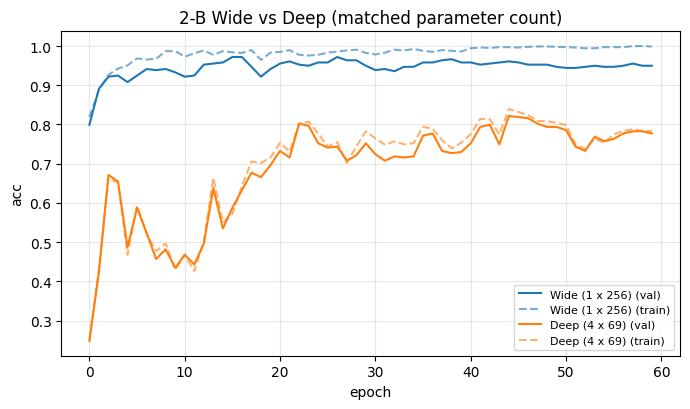


[여러 시드에서 반복]
  seed=0      wide=0.9444  deep=0.8833
  seed=1      wide=0.9639  deep=0.8222
  seed=42     wide=0.9639  deep=0.7611
  seed=8734   wide=0.9444  deep=0.7667
  seed=7777   wide=0.9556  deep=0.8694

Wide 평균 = 0.9544 (표준편차 0.0087)
Deep 평균 = 0.8206 (표준편차 0.0505)
Wide 가 이긴 횟수: 5 / 5


In [ ]:
# ── 2-B. Wide vs Deep (파라미터 수를 맞춘 공정 비교) ─────────────

# (1) 파라미터 수 맞추기 — Deep 쪽 h 를 직접 찾으세요
H = 256
wide = build_mlp(hidden=(H,))
print(f"Wide 64-{H}-10 파라미터 수 = {count_params(wide)}")

# TODO: 은닉층 4개짜리 Deep 모델의 폭 h 를 정하라.
#       3h^2 + 78h + 10 이 위 숫자와 10% 이내가 되도록. (h 를 몇 개 넣어 보며 찾아도 좋다)
h = 69
deep = build_mlp(hidden=(h, h, h, h))
print(f"Deep 64-{h}x4-10 파라미터 수 = {count_params(deep)}")

diff_pct = abs(count_params(wide) - count_params(deep)) / count_params(wide) * 100
print(f"파라미터 수 차이 = {diff_pct:.2f}%  -> 10% 이내여야 공정한 비교")
assert diff_pct < 10, "파라미터 수가 10% 넘게 차이납니다. h 를 다시 고르세요."

# (2) 동일 조건으로 학습 후 비교
hist2b = {}
for tag, m in [(f"Wide (1 x {H})", wide), (f"Deep (4 x {h})", deep)]:
    hist2b[tag] = train_model(m, epochs=60)
    _, te_acc = evaluate(m, Xte, yte)
    print(f"{tag:<16} final val_acc = {hist2b[tag]['val_acc'][-1]:.4f} | "
          f"best val_acc = {max(hist2b[tag]['val_acc']):.4f} | test_acc = {te_acc:.4f} | "
          f"final train_loss = {hist2b[tag]['train_loss'][-1]:.4f}")

plot_curves(hist2b, "2-B Wide vs Deep (matched parameter count)", metric="acc")

# (3) 시드 하나로 결론 내지 않기 — 5개 시드에서 반복
print("\n[여러 시드에서 반복]")
wide_scores, deep_scores = [], []
for s in [0, 1, 42, MY_SEED, 7777]:
    w = build_mlp(hidden=(H,), seed=s)
    d = build_mlp(hidden=(h, h, h, h), seed=s)
    train_model(w, epochs=60, seed=s)
    train_model(d, epochs=60, seed=s)
    # TODO: 각 모델의 test accuracy 를 리스트에 담아라
    wide_scores.append(evaluate(w, Xte, yte)[1])
    deep_scores.append(evaluate(d, Xte, yte)[1])
    print(f"  seed={s:<6} wide={wide_scores[-1]:.4f}  deep={deep_scores[-1]:.4f}")

print(f"\nWide 평균 = {np.mean(wide_scores):.4f} (표준편차 {np.std(wide_scores):.4f})")
print(f"Deep 평균 = {np.mean(deep_scores):.4f} (표준편차 {np.std(deep_scores):.4f})")
print(f"Wide 가 이긴 횟수: {sum(w > d for w, d in zip(wide_scores, deep_scores))} / 5")

**Q2-B. (본인 출력값 인용 + 판단)**

**(1) 파라미터 맞추기.** 본인이 고른 `h`는 얼마이고 Deep의 파라미터 수는 몇 개인가요? Wide와 몇 % 차이인가요? **왜 파라미터 수를 맞춰야 공정한 비교**가 되는지 한 문장으로 쓰세요.
제가 고른 h는 69이고 Deep의 파라미터 수는 19,675개이다. Wide의 파라미터 수는 19,210개이므로 두 모델의 파라미터 수 차이는 2.42%이다. 파라미터 수를 비슷하게 맞춰야 한쪽이 단순히 더 많은 모델 용량을 가진 것 때문에 성능이 좋아지는 효과를 제외하고 네트워크 구조 자체의 차이를 공정하게 비교할 수 있기 때문이다
**(2) 단일 시드 결과.** Wide와 Deep의 test accuracy를 적으세요. 강의 p.36의 결론("Deep이 파라미터를 더 효율적으로 사용해 높은 성능")이 **본인 실험에서 재현되었나요?**
Wide test accuracy = 0.9444
Deep test accuracy = 0.7667
Deep이 파라미터를 더 효율적으로 사용해 높은 성능을 낸다”는 결론이 재현되지 않았다
**(3) 5개 시드 결과.** Wide/Deep의 평균과 표준편차, 그리고 Wide가 이긴 횟수를 적으세요. 만약 (2)의 결론이 5개 시드에서도 유지된다면 **"시드 운"이 아니라는 근거**가 됩니다. 유지되었나요?
Wide 평균 = 0.9544
Wide 표준편차 = 0.0087
Deep 평균 = 0.8206
Deep 표준편차 = 0.0505
Wide가 이긴 횟수 = 5 / 5
5개의 서로 다른 시드에서 모두 Wide가 Deep보다 높은 성능을 보였기 때문에 이번 실험에서는 시드 운만으로 결과를 설명하기 어렵다
**(4) 원인 추론 — 여기가 핵심입니다.** 결과가 강의와 달랐다면, 그 원인으로 다음 중 무엇을 의심하겠습니까? 최소 두 가지를 고르고 본인 데이터의 구체적 숫자로 근거를 대세요.
- (a) 데이터가 너무 작다 (훈련 샘플 몇 개인지 적을 것)
- (b) 입력이 8×8 = 64차원으로 단순해 계층적 특징이 필요 없다
- (c) Deep 쪽이 아직 수렴하지 않았다 (양쪽 `final train_loss`를 비교해 판단할 것)
- (d) 4층 정도로는 "Deep"이라 하기 부족하다
- (e) 규제·학습률을 Deep에 맞게 따로 튜닝하지 않았다
(a) 데이터가 작다는 점을 의심할 수 있다. Digits 데이터는 전체 1,797개로 학습 데이터가 1078개뿐이어서 깊은 모델을 학습하기에 충분하지 않을 수 있다.

또한 (c) Deep이 충분히 수렴하지 않았을 가능성도 있다. Wide의 final train_loss는 0.0031인데 Deep은 0.9217로 훨씬 높아서 Deep이 학습 데이터에서도 제대로 학습되지 않았음을 보여준다

**(5) 조건을 붙여 다시 쓰기.** 강의 p.36의 문장을 **본인 실험 결과와 모순되지 않게** 조건을 붙여 고쳐 쓰세요. (예: "____ 한 조건에서는 Deep이 ____ 하다.") 그리고 실제로 Deep이 압도적으로 유리한 대표 사례를 강의 5장(Expansion into Modern AI)에서 하나 골라, **왜 그 도메인에서는 다른지** 한 문장으로 설명하세요
충분한 데이터와 적절한 학습 조건이 갖춰지고 계층적인 특징 학습이 필요한 문제에서는 Deep이 파라미터를 더 효율적으로 사용할 수 있다 대표적으로 컴퓨터 비전에서는 CNN과 ResNet 같은 Deep 모델이 사용되는데 강의자료59페이지를 보면 볼수있듯이  이미지의 특징을 계층적으로 학습하기에 적합하기 때문이다.

---

### 2-C. 나만의 최고 모델 만들기 (유형 C 맛보기)

지금까지의 실험에서 배운 것을 **하나의 모델에 종합**합니다.

**규칙**
1. **데이터 분할은 고정** — `Xtr / Xva / Xte`를 그대로 쓰세요. (새로 나누면 비교가 무의미해집니다.)
2. **test는 마지막에 딱 한 번만.** 모든 튜닝 결정은 **val**로 하세요. test를 보고 하이퍼파라미터를 고르면 그건 test가 아니라 두 번째 val입니다.
3. **방법은 자유** — 층 수·폭·활성화 함수·Dropout·L2·학습률·optimizer·batch size·epoch 수·Early Stopping 등 무엇이든.
4. **실험 기록 필수** — 시도한 조건과 val 성능을 아래 `log` 리스트에 **모두** 남기세요. 실패한 실험도 포함합니다.

**평가는 최종 정확도만 보지 않습니다.** *어떤 가설을 세워 무엇을 바꿨고, 결과가 그 가설을 지지했는지* 를 함께 봅니다.

> 💡 **출발점 힌트:** §1.2 baseline은 test 0.9667이었습니다. §1.4에서 L2가 효과적이었고, §1.5에서 Adam/Momentum이 빨랐으며, §2-B에서 이 데이터에는 Wide가 유리했습니다. 여기에 Early Stopping(val_loss 최저 시점의 가중치를 저장해 두었다가 복원)을 더하면 어떨까요?

In [ ]:
# ── 2-C. 나만의 최고 모델 ──────────────────────────────────────
# 규칙: 튜닝 판단은 반드시 val 로! test 는 맨 마지막 한 번만.

log = []   # (설명, 하이퍼파라미터, best_val_acc) 를 모두 기록 — 실패한 실험도 남길 것

def try_config(desc, hidden, act=nn.ReLU, p_drop=0.0, wd=0.0,
               opt_name="adam", lr=1e-3, epochs=80, batch_size=64):
    """조건 하나를 학습하고 val 성능을 기록한다. (test 는 건드리지 않는다)"""
    m = build_mlp(hidden=hidden, act=act, p_drop=p_drop)
    h = train_model(m, epochs=epochs, opt_name=opt_name, lr=lr,
                    weight_decay=wd, batch_size=batch_size)
    best_val = max(h["val_acc"])
    best_ep  = int(np.argmin(h["val_loss"])) + 1
    log.append((desc, best_val, best_ep, count_params(m)))
    print(f"{desc:<38} best_val_acc={best_val:.4f}  (val_loss 최저 ep={best_ep}, params={count_params(m)})")
    return m, h

# ── 예시로 두 개만 돌려 둡니다. 아래에 본인 실험을 최소 4개 이상 추가하세요. ──
try_config("A. baseline 재현 (64,32)", hidden=(64, 32))
try_config("B. Wide + 약한 L2", hidden=(256,), wd=1e-4)

# TODO: 본인 실험을 최소 4개 추가하세요. 아무거나 찍지 말고 '가설 -> 검증' 형태로.
#   예) 가설: §1.4처럼 L2 가 도움이 된다면 wd 를 키울수록 val 이 좋아질 것이다
#       try_config("C. Wide + wd=1e-3", hidden=(256,), wd=1e-3)
#   예) 가설: §2-B 에서 Wide 가 유리했으니 더 넓히면 더 좋아질 것이다
#       try_config("D. 더 넓게 (512,)", hidden=(512,))
# C. Wide + 강한 L2
try_config(
    "C. Wide + 강한 L2",
    hidden=(256,),
    wd=1e-3
)

# D. 더 넓게
try_config(
    "D. 더 넓게 (512,)",
    hidden=(512,)
)

# E. Wide + Dropout
try_config(
    "E. Wide + Dropout",
    hidden=(256,),
    p_drop=0.2
)

# F. Wide + L2 + Dropout
try_config(
    "F. Wide + L2 + Dropout",
    hidden=(256,),
    p_drop=0.2,
    wd=1e-4
)


# ── 최종 선택 & 단 한 번의 test 평가 ──────────────────────────
print("\n" + "=" * 70)
print(f"{'실험':<40}{'best_val_acc':>14}{'best_ep':>9}{'params':>8}")
print("-" * 70)
for desc, bv, be, npar in sorted(log, key=lambda r: -r[1]):
    print(f"{desc:<40}{bv:>14.4f}{be:>9}{npar:>8}")

# TODO: 위 표에서 val 성능이 가장 좋았던 조건을 골라 아래에 그대로 다시 설정하라
FINAL_HIDDEN   = (256,)
FINAL_DROPOUT  = 0.0
FINAL_WD       =  1e-3
FINAL_OPT      = "adam"
FINAL_LR       = 1e-3
FINAL_EPOCHS   =  80

final_model = build_mlp(hidden=FINAL_HIDDEN, p_drop=FINAL_DROPOUT)
final_hist  = train_model(final_model, epochs=FINAL_EPOCHS, opt_name=FINAL_OPT,
                          lr=FINAL_LR, weight_decay=FINAL_WD)

final_test_loss, final_test_acc = evaluate(final_model, Xte, yte)
print("\n" + "=" * 70)
print(f"[최종 모델] val 최고 = {max(final_hist['val_acc']):.4f}")
print(f"[최종 모델] TEST accuracy = {final_test_acc:.4f}  (baseline 대비 "
      f"{final_test_acc - test_acc:+.4f})")
print("=" * 70)

A. baseline 재현 (64,32)                 best_val_acc=0.9359  (val_loss 최저 ep=6, params=6570)
B. Wide + 약한 L2                        best_val_acc=0.9721  (val_loss 최저 ep=3, params=19210)
C. Wide + 강한 L2                        best_val_acc=0.9749  (val_loss 최저 ep=3, params=19210)
D. 더 넓게 (512,)                         best_val_acc=0.9749  (val_loss 최저 ep=2, params=38410)
E. Wide + Dropout                      best_val_acc=0.9749  (val_loss 최저 ep=3, params=19210)
F. Wide + L2 + Dropout                 best_val_acc=0.9749  (val_loss 최저 ep=3, params=19210)

실험                                        best_val_acc  best_ep  params
----------------------------------------------------------------------
C. Wide + 강한 L2                                 0.9749        3   19210
D. 더 넓게 (512,)                                  0.9749        2   38410
E. Wide + Dropout                               0.9749        3   19210
F. Wide + L2 + Dropout                          0.9749        3   19210
B. Wide + 약

**Q2-C. 전략 보고서 (텍스트로 서술)**

**(1) 실험 로그.** 위 표를 그대로 옮기고, **실패한 실험도 포함**해 최소 6개를 보고하세요.
| 실험                     | best val accuracy | best epoch | 파라미터 수 |
| ---------------------- | ----------------: | ---------: | -----: |
| A. baseline 재현 (64,32) |            0.9359 |          6 |  6,570 |
| B. Wide + 약한 L2        |            0.9721 |          3 | 19,210 |
| C. Wide + 강한 L2        |            0.9749 |          3 | 19,210 |
| D. 더 넓게 (512,)         |            0.9749 |          2 | 38,410 |
| E. Wide + Dropout      |            0.9749 |          3 | 19,210 |
| F. Wide + L2 + Dropout |            0.9749 |          3 | 19,210 |


**(2) 가설 → 검증.** 시도한 것 중 **가설이 맞았던 것 하나**와 **가설이 틀렸던 것 하나**를 골라, 각각 이렇게 정리하세요.

**(3) 최종 선택의 근거.** 왜 그 조건을 최종 모델로 골랐나요? **val 기준으로** 설명하세요.
Wide + L2를 적용하면 baseline보다 validation accuracy가 높아질 것이다 왜냐하면 §1.4에서 L2 규제가 효과적이었던 것을 봤기 때문이다
결과: val accuracy 0.9359 → 0.9721
판정 및 해석: 가설이 맞았다 Wide 구조에 약한 L2 규제를 추가하자 validation accuracy가 크게 향상되었다
가설이 틀렸던 경우

가설: Dropout을 추가하면 validation accuracy가 더 높아질 것이다 왜냐하면 Dropout이 과적합을 줄여 일반화 성능을 높일 수 있기 때문이다
결과: val accuracy 0.9721 → 0.9749 (Wide + 약한 L2 → Wide + Dropout)
판정 및 해석: 성능은 약간 높아졌지만 기대했던 추가적인 개선이 뚜렷하지 않았다 특히 E, F 모두 0.9749로 동일하여 Dropout을 추가한 것이 결정적인 성능 향상을 만들었다고 보기는 어렵다
**(4) val과 test의 간극.** 최종 모델의 best val accuracy와 test accuracy를 나란히 적으세요. 어느 쪽이 높나요? val이 test보다 높다면 그 이유는 무엇일까요? (힌트: val은 이미 **선택에 사용된** 데이터입니다.)
최종 모델의 best val accuracy는 0.9749, test accuracy는 0.9500이다. 따라서 val accuracy가 test accuracy보다 0.0249 높았다. Validation set은 여러 모델과 하이퍼파라미터를 비교하고 최종 모델을 선택하는 데 사용되었기 때문에, 선택 과정에서 validation set에 맞춰진 결과가 반영될 수 있다. 따라서 최종적으로 처음 확인하는 test set보다 val accuracy가 높게 나타날 수 있다
**(5) 정직하게.** 만약 test를 여러 번 보면서 튜닝했다면, 그 test accuracy는 왜 **실제 성능의 과대평가**인가요? 이것이 §1.1에서 배운 데이터 누수와 어떻게 같은 문제인지 설명하세요.
test set을 여러 번 확인하면서 모델이나 하이퍼파라미터를 튜닝하면 test set의 정보가 모델 선택 과정에 간접적으로 사용된다 그러면 test 성능이 좋은 조건을 반복해서 선택하게 되어 실제 새로운 데이터에서의 성능보다 test accuracy가 높게 평가될 수 있다 이는 §1.1에서 배운 데이터 누수와 같은 문제이다. 원래 모델 평가에만 사용해야 하는 test set의 정보가 모델 선택에 들어가면서 test set이 더 이상 독립적인 평가 데이터가 아니게 되기 때문이다

## 3. 결론

`digits`(1,797장, 8×8) 위에서 **데이터 준비 → MLP 학습 → 세 가지 고질병 실험 → 구조 비교**를 진행했습니다. 각 항목을 **본인이 뽑은 값**을 근거로 정리하세요.

- **기본 MLP 학습 (§1.2):** 모델의 파라미터 수와 test accuracy는 얼마였나요? train/val loss 곡선에서 Early Stopping이 필요해 보인 시점과 그 근거는? → 모델의 파라미터 수는 6,570개, test accuracy는 0.9694였다 Val loss는 60 epoch에서 0.0669로 가장 낮았으며 마지막 epoch에서도 train loss 0.0030, val loss 0.0669로 학습이 진행되었다 따라서 이 실험에서는 60 epoch까지는 학습이 필요했으며 이 결과만으로 더 이른 Early Stopping이 필요하다고 보기는 어렵다
- **Vanishing Gradient (§1.3):** Sigmoid 8층의 첫 층 gradient norm ____ vs 마지막 층 ____. 이 차이가 train accuracy ____로 이어진 인과를 한 문장으로:
Sigmoid 8층의 첫 층 gradient norm은 1.40e-07 마지막 층은 2.59e-01이었다 이처럼 앞쪽 층의 gradient가 매우 작아져 학습이 제대로 이루어지지 않아 train accuracy가 0.1011에 그쳤다.
- **Overfitting (§1.4):** baseline의 gap(val_loss − train_loss) = ____, Early Stopping 시점 = epoch ____. 네 처방 중 본인 데이터에서 최선이었던 것과 그 이유: baseline의 val_loss − train_loss gap은 126.2939였고 validation loss가 최소였던 Early Stopping 시점은 epoch 6이었다. 네 가지 조건 중에서는 Dropout p=0.5가 best val accuracy 0.9331로 가장 높아 과적합 완화에 가장 효과적이었다. 반면 L2는 wd=1e-2에서 0.9025 wd=1e-1에서도 0.9025로 baseline의 0.9053보다 낮아 이 데이터와 설정에서는 L2가 효과적이었다고 보기 어렵다
- **Optimization (§1.5):** val 90% 도달 epoch — SGD ____ / Momentum ____ / Adam ____. "수렴 속도"와 "최종 성능"이 다른 이야기인 이유: al accuracy 90%에 도달한 epoch는 SGD = 4, Momentum = 도달하지 못함(None), Adam = 15였다. SGD는 가장 빠르게 90%에 도달했지만, Adam은 최종적으로 best val accuracy 0.9331을 기록한 반면 SGD는 0.9136이었다. 따라서 수렴 속도는 목표 성능에 얼마나 빨리 도달하는지를 의미하고, 최종 성능은 학습이 끝난 뒤 얼마나 높은 성능을 내는지를 의미하므로 서로 다른 개념이다
- **구조 (§2-A, §2-B):** 활성화 함수를 없앴을 때 접기 오차 ____가 증명한 것은? 파라미터를 맞춘 Wide vs Deep에서 이긴 쪽과, 그 결과가 강의 슬라이드와 달랐다면 그 조건은? 활성화 함수를 없앴을 때 접기 오차가 9.766e-04로 매우 작았다는 것은 여러 선형층을 하나의 선형변환으로 합칠 수 있어 활성화 함수가 없으면 층을 깊게 쌓아도 본질적으로 하나의 선형 모델과 같다는 것을 보여준다 파라미터 수를 맞춘 Wide vs Deep에서는 Wide가 승리했으며, 이는 이 작은 8×8 Digits 데이터에서는 강의의 Deep이 파라미터를 더 효율적으로 사용해 높은 성능을 낸다는 일반적인 결론이 그대로 재현되지 않았음을 보여준다
- **한 문장 요약:** 이번 과제에서 **강의 슬라이드의 일반론이 본인 데이터에서는 성립하지 않았던 사례**를 하나 고르고, 거기서 배운 교훈을 한 문장으로: Digits 데이터에서는 Deep보다 Wide가 더 좋은 성능을 보였으며, 모델 구조의 장점은 데이터의 크기와 복잡성, 그리고 학습 조건에 따라 달라질 수 있다는 것을 배웠다

## 4. 회고

겪은 어려움과 해결 과정을 3~5문장으로 적습니다. 끝까지 헷갈린 개념(gradient 누적, Dropout의 train/eval 차이, val과 test의 역할 구분, 규제 강도의 trade-off 등) 1~3개도 함께: (여기에 답)
Dropout은 학습할 때와 평가할 때 동작 방식이 다르다는 점이 헷갈렸고, 실험 결과를 비교하면서 이를 이해했다 특히 val은 모델과 하이퍼파라미터 선택에 사용하고 test는 최종 평가에만 사용해야 한다는 차이를 구분하는 것이 중요하다는 것을 배웠다
## 5. 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): (여기에 답)

- **AI가 이 실험에는 틀린 답을 준 사례** — 예를 들면 다음과 같은 오류가 자주 나옵니다.
  - 모델 마지막에 `nn.Softmax`를 붙이는 코드 (`CrossEntropyLoss`와 중복)
  - "학습률이 크면 항상 발산한다"고 조건 없이 단정
  - "Dropout을 쓰면 성능이 좋아진다"고 단정 (§1.4 본인 결과와 비교)
  - "Deep이 Wide보다 낫다"고 단정 (§2-B 5개 시드 결과와 비교)
  - 존재하지 않는 인자·API 이름을 사용하거나, 앞 셀에서 정의한 변수명(`train_model`, `hist_base` 등)을 무시

  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: (여기에 답)

- **실제 대화 내역** 붙여넣기:

```
(여기에 AI와의 실제 대화 내역을 붙여넣기)
```# C. Wide + 강한 L2
try_config(
    "C. Wide + 강한 L2",
    hidden=(256,),
    wd=1e-3
)

# D. 더 넓게
try_config(
    "D. 더 넓게 (512,)",
    hidden=(512,)
)

# E. Wide + Dropout
try_config(
    "E. Wide + Dropout",
    hidden=(256,),
    p_drop=0.2
)

# F. Wide + L2 + Dropout
try_config(
    "F. Wide + L2 + Dropout",
    hidden=(256,),
    p_drop=0.2,
    wd=1e-4
)

이거같은 코딩 디버깅 문제들을 다수 사용했습니다

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? 여러 실험의 결과를 직접 비교하고 내 데이터에서는 어떤 모델과 규제 방법이 더 적절한지 선택한 것
